# Chapter 2 — Gromov-Wasserstein on two rotated 2D clouds (companion notebook)

Executable companion to `chapter.md`. Imports `src/ot_steering/ot/gw.py` and the shared demo from `phases/phase_02_gromov_wasserstein/experiments/demo.py` so the notebook runs the same code that ships in the repo.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

experiments_dir = Path.cwd() / "experiments"
if str(experiments_dir) not in sys.path:
    sys.path.insert(0, str(experiments_dir))

from demo import run_rotation_demo  # noqa: E402
from make_figures import (  # noqa: E402
    _fig_two_clouds,
    _fig_coupling_lines,
    _fig_coupling_heatmap,
    _fig_recovered_vs_truth,
)

print("loaded demo from", experiments_dir)

loaded demo from /home/adimunot21/projects/ot-concept-transport/phases/phase_02_gromov_wasserstein/experiments


## 1. Two clouds, no shared coordinate frame

We sample 80 points in 2D, then rotate them by a random angle and add a small amount of noise. From the algorithm's point of view, the two clouds live in *different* spaces — the rotation is not given. The only thing that survives the rotation is the matrix of *intra-cloud* pairwise distances, and that is exactly what GW will work from.

n = 80
GW cost = 0.006255971134622263
recovery accuracy = 92%


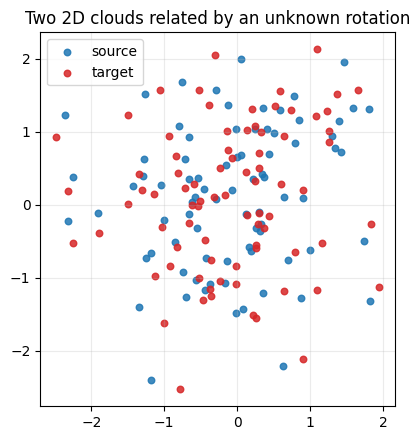

In [2]:
demo = run_rotation_demo()
print("n =", demo.source.shape[0])
print("GW cost =", demo.gw_cost)
print("recovery accuracy =", f"{demo.accuracy:.0%}")
fig = _fig_two_clouds(demo)
plt.show()

## 2. The GW coupling, drawn as lines

Each line is a non-zero coupling entry $P_{ij}$. The picture should look like a near-perfect bipartite matching across the gap between the clouds — even though the solver was never told the rotation.

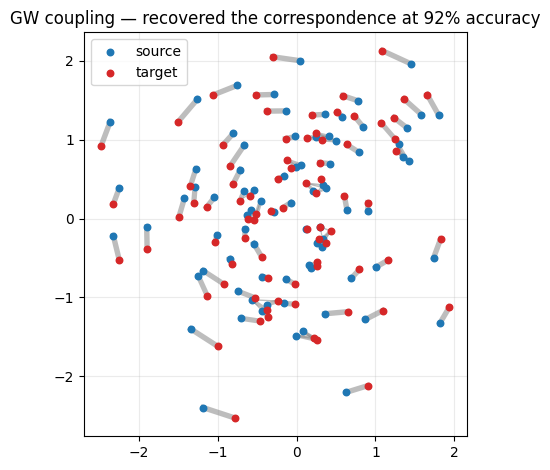

In [3]:
fig = _fig_coupling_lines(demo)
plt.show()

## 3. The coupling as a matrix

The left panel is the raw $P$. The right panel sorts the rows by the recovered argmax target so a *near-diagonal* lights up — that diagonal is the planted permutation, recovered from intra-distance information alone.

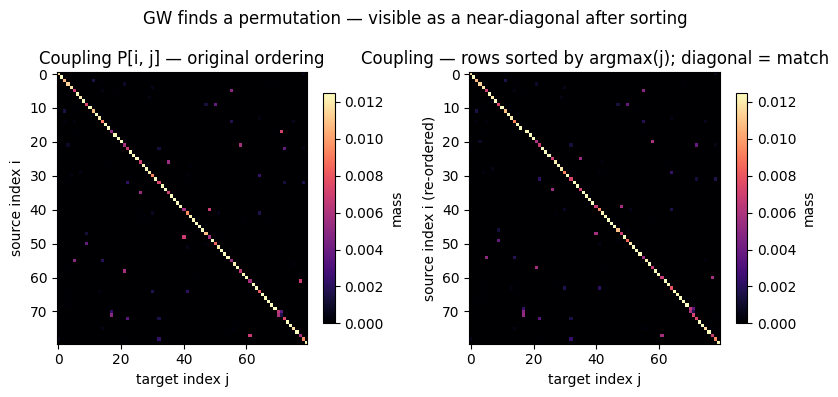

In [4]:
fig = _fig_coupling_heatmap(demo)
plt.show()

## 4. Recovered vs. planted correspondence

Each dot is a source point. Its $x$ coordinate is the planted partner index in the target cloud; its $y$ coordinate is the argmax of the GW coupling. Perfect recovery is the dashed diagonal.

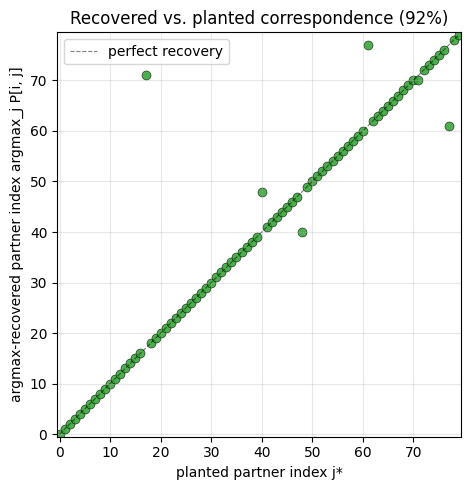

In [5]:
fig = _fig_recovered_vs_truth(demo)
plt.show()

## What we just learned

- Standard OT needs a pointwise cost across the two spaces. Gromov-Wasserstein replaces that with intra-distance matrices, and so applies to clouds that have no shared coordinate frame at all.
- The GW objective is *quadratic* in the coupling, which means it is non-convex. We mitigate this with multiple random restarts of the projected-gradient solver and keep the lowest-cost run.
- On a 2D rotation toy, entropic GW recovers the planted correspondence cleanly — the structural-matching reflex this chapter installed is the same reflex we will use for cross-LLM alignment in Phase 5.

Next: Phase 3 introduces the language models and the activation-extraction stack that GW will eventually be run on.